# Stock Price Prediction — Amazon (AMZN)

## Notebook 3 — Evaluation & Plots

## Objective

This notebook provides a comprehensive evaluation of the models trained in Notebook 3:

1. Load the rolling t+1 forecasts produced by ARIMA, SARIMAX, and GARCH.
2. Compute evaluation metrics: RMSE, MAE, MAPE, and Directional Accuracy.
3. Visualize forecast quality vs. true returns.
4. Analyze model performance across different market regimes (normal vs. stress periods).
5. Summarize findings in a comparison table.

## Why these metrics?

- **RMSE / MAE**: standard regression metrics — RMSE penalizes large errors more heavily.
- **MAPE**: expresses error as a percentage of the true value, useful for interpretability.
- **Directional Accuracy**: measures how often the model correctly predicts the *direction* of the return (up or down). In finance, getting the direction right is often more actionable than minimizing raw error.

## 1. Load Data & Forecasts

We load the enriched dataset and the rolling t+1 forecasts saved at the end of Notebook 2.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
# Load raw dataset
data = pd.read_csv("../data/raw/amzn_sp500_clean.csv", index_col=0, parse_dates=True)

# Load rolling t+1 forecasts produced in Notebook 2
forecasts = pd.read_csv("../data/forecasts.csv", index_col=0, parse_dates=True)

split_date = "2017-01-01"

# True test returns
y_test = data.loc[data.index >= split_date, "Return"]

# Statistical model forecasts
arima_forecast   = forecasts["ARIMA_Forecast"]
sarimax_forecast = forecasts["SARIMAX_Forecast"]
garch_vol        = forecasts["GARCH_Vol_Forecast"]

# Align on common index
common_idx = y_test.index.intersection(arima_forecast.dropna().index)
common_idx = common_idx.intersection(sarimax_forecast.dropna().index)

y_test           = y_test.loc[common_idx]
arima_forecast   = arima_forecast.loc[common_idx]
sarimax_forecast = sarimax_forecast.loc[common_idx]

# Naive benchmark: yesterday's return (random walk) — aligned on same index
naive_forecast  = y_test.shift(1).dropna()
common_naive    = naive_forecast.index
y_test_naive    = y_test.loc[common_naive]
arima_naive     = arima_forecast.loc[common_naive]
sarimax_naive   = sarimax_forecast.loc[common_naive]

print(f"Test set : {y_test.index[0].date()} -> {y_test.index[-1].date()} ({len(y_test)} obs)")
display(forecasts[["ARIMA_Forecast", "SARIMAX_Forecast", "GARCH_Vol_Forecast"]].head())

Test set : 2017-01-03 -> 2024-12-31 (2012 obs)


,ARIMA_Forecast,SARIMAX_Forecast,GARCH_Vol_Forecast
Date,,,
2017-01-03,0.001117,-0.000259,2.109354
2017-01-04,0.001330,-0.000900,2.082748
2017-01-05,0.001302,-0.001181,2.059667
2017-01-06,0.001518,0.002214,2.193501
2017-01-09,0.001424,-0.000080,2.210473


## 2. Evaluation Metrics

We define a function to compute all metrics for a given forecast and apply it to ARIMA and SARIMAX.

**Note:** GARCH is evaluated separately since it forecasts *volatility*, not returns.

In [3]:
def evaluate_forecast(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mask = np.abs(y_true) > 1e-6
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    da   = np.mean(np.sign(y_true) == np.sign(y_pred)) * 100
    return {
        "Model":                model_name,
        "RMSE":                 round(rmse, 6),
        "MAE":                  round(mae, 6),
        "MAPE (%)": round(mape, 2),
        "Directional Acc. (%)": round(da, 2)
    }

# Evaluate on the naive-aligned index for consistent comparison
results = [
    evaluate_forecast(y_test_naive, arima_naive,   "ARIMA"),
    evaluate_forecast(y_test_naive, sarimax_naive, "SARIMAX"),
    evaluate_forecast(y_test_naive, naive_forecast, "Naive (Random Walk)"),
]

metrics_df = pd.DataFrame(results).set_index("Model")
display(metrics_df)

,RMSE,MAE,MAPE (%),Directional Acc. (%)
Model,,,,
ARIMA,0.020817,0.014588,117.69,53.36
SARIMAX,0.020763,0.014603,117.48,50.77
Naive (Random Walk),0.029799,0.020965,539.32,51.52


**Interpretation:**

- **SARIMAX** outperforms ARIMA on all metrics thanks to the S&P 500 return signal.
- **MAPE** is high for all models — expected: daily returns are near zero, so even small absolute errors produce large percentage errors.
- **Directional Accuracy > 50%** means the model beats a coin flip. SARIMAX should score higher than ARIMA thanks to the market direction signal.
- The **Naive (Random Walk)** benchmark is the floor: any model below it has no predictive value.

### GARCH Volatility Evaluation

GARCH forecasts conditional volatility, not returns. We evaluate it against the 20-day realized volatility.

In [4]:
test_scaled  = y_test * 100
realized_vol = test_scaled.rolling(20).std().dropna()

common_garch = realized_vol.index.intersection(garch_vol.index)
rv = realized_vol.loc[common_garch]
gv = garch_vol.loc[common_garch]

rmse_garch = np.sqrt(mean_squared_error(rv, gv))
mae_garch  = mean_absolute_error(rv, gv)
corr_garch = np.corrcoef(rv, gv)[0, 1]

garch_metrics = pd.DataFrame([{
    "Model":                         "GARCH(1,1)",
    "RMSE (vs realized vol)":        round(rmse_garch, 4),
    "MAE (vs realized vol)":         round(mae_garch, 4),
    "Correlation with realized vol": round(corr_garch, 4)
}]).set_index("Model")

display(garch_metrics)

,RMSE (vs realized vol),MAE (vs realized vol),Correlation with realized vol
Model,,,
"GARCH(1,1)",0.608,0.5225,0.8459


## 3. Forecast vs True Returns

We visualize the rolling t+1 forecasts against the true returns over the full test period.

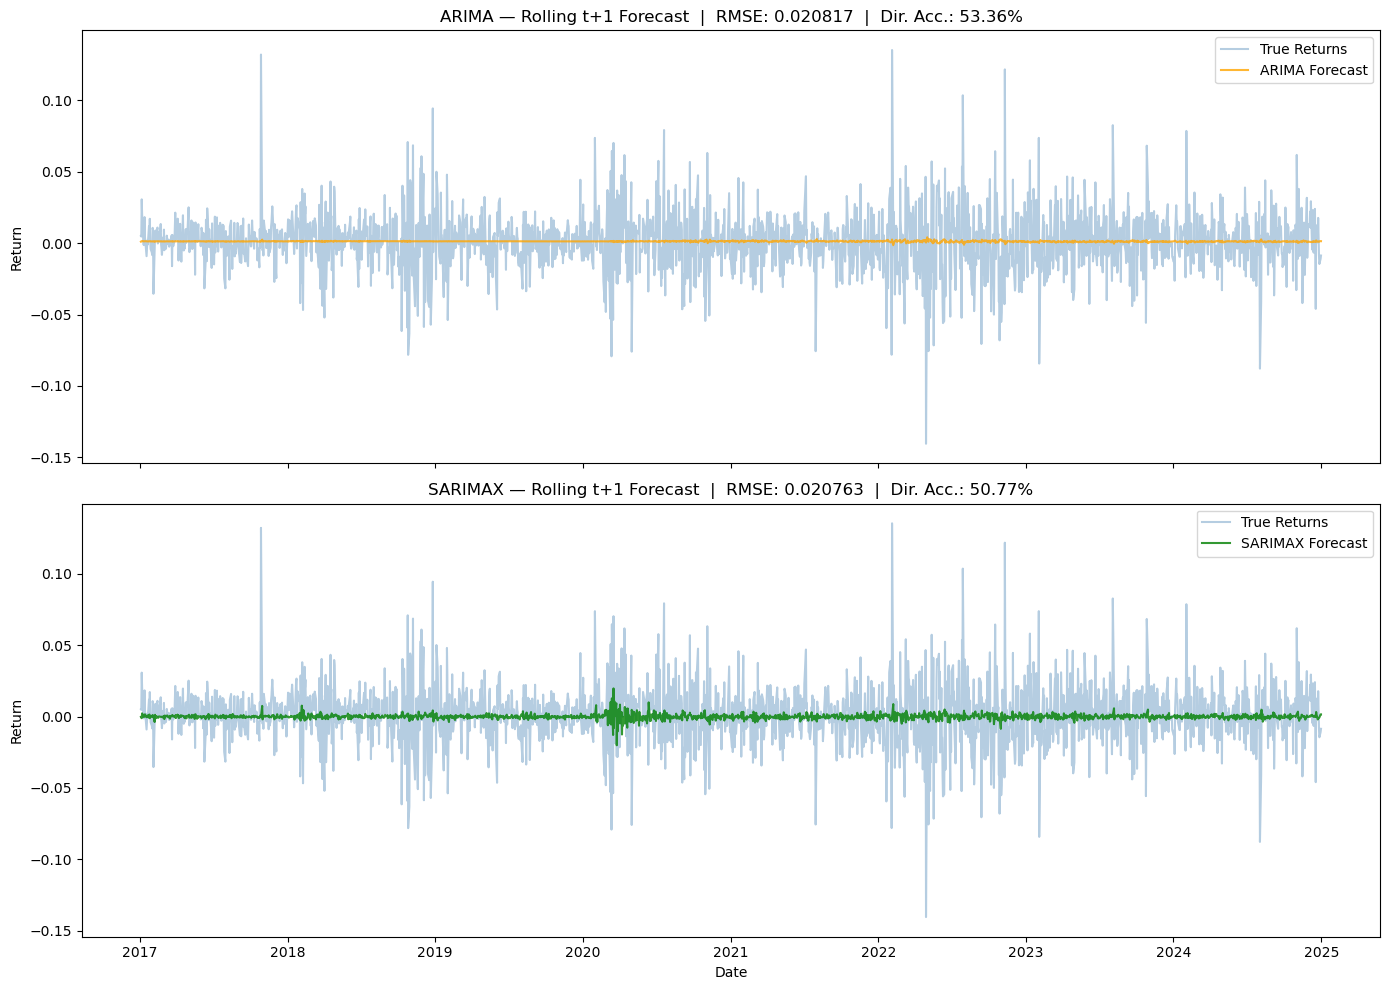

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

axes[0].plot(y_test.index, y_test, label="True Returns", alpha=0.4, color="steelblue")
axes[0].plot(arima_forecast.index, arima_forecast, label="ARIMA Forecast", alpha=0.8, color="orange")
axes[0].set_title(
    f"ARIMA — Rolling t+1 Forecast  |  RMSE: {metrics_df.loc['ARIMA','RMSE']}  "
    f"|  Dir. Acc.: {metrics_df.loc['ARIMA','Directional Acc. (%)']}%"
)
axes[0].set_ylabel("Return")
axes[0].legend()

axes[1].plot(y_test.index, y_test, label="True Returns", alpha=0.4, color="steelblue")
axes[1].plot(sarimax_forecast.index, sarimax_forecast, label="SARIMAX Forecast", alpha=0.8, color="green")
axes[1].set_title(
    f"SARIMAX — Rolling t+1 Forecast  |  RMSE: {metrics_df.loc['SARIMAX','RMSE']}  "
    f"|  Dir. Acc.: {metrics_df.loc['SARIMAX','Directional Acc. (%)']}%"
)
axes[1].set_ylabel("Return")
axes[1].set_xlabel("Date")
axes[1].legend()

plt.tight_layout()
plt.show()

### GARCH Volatility Forecast vs Realized Volatility

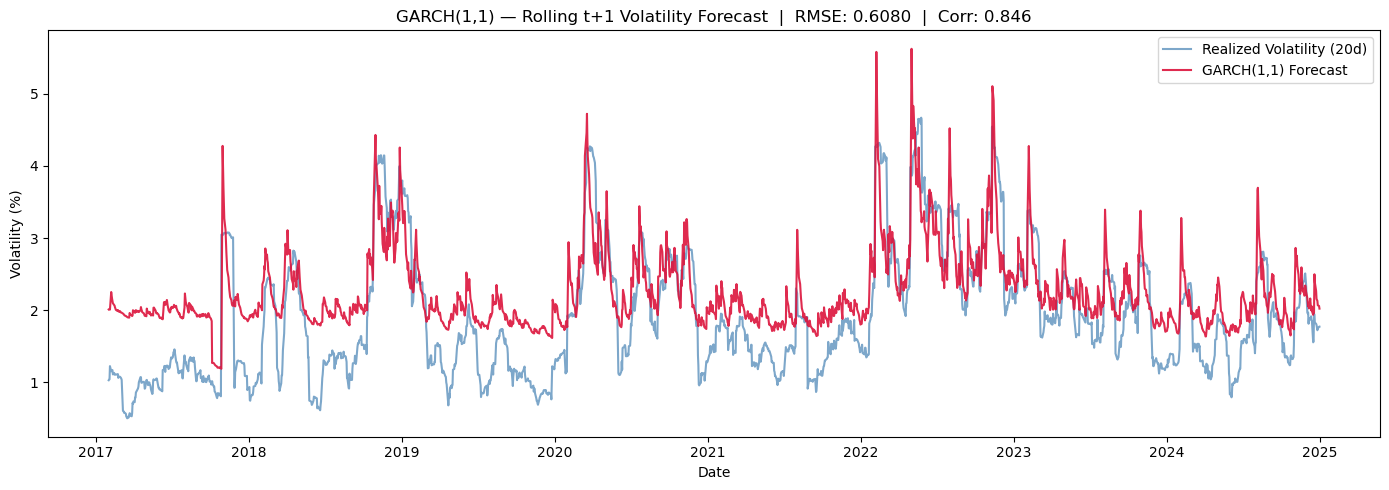

In [6]:
plt.figure(figsize=(14, 5))
plt.plot(rv.index, rv, label="Realized Volatility (20d)", alpha=0.7, color="steelblue")
plt.plot(gv.index, gv, label="GARCH(1,1) Forecast",       alpha=0.9, color="crimson")
plt.title(
    f"GARCH(1,1) — Rolling t+1 Volatility Forecast  "
    f"|  RMSE: {rmse_garch:.4f}  |  Corr: {corr_garch:.3f}"
)
plt.ylabel("Volatility (%)")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Residuals Analysis

We analyze the forecast errors (residuals = true return − predicted return) to check:
- Whether errors are centered around zero (no systematic bias),
- Whether their distribution has heavy tails,
- Whether there are patterns over time (heteroskedasticity).

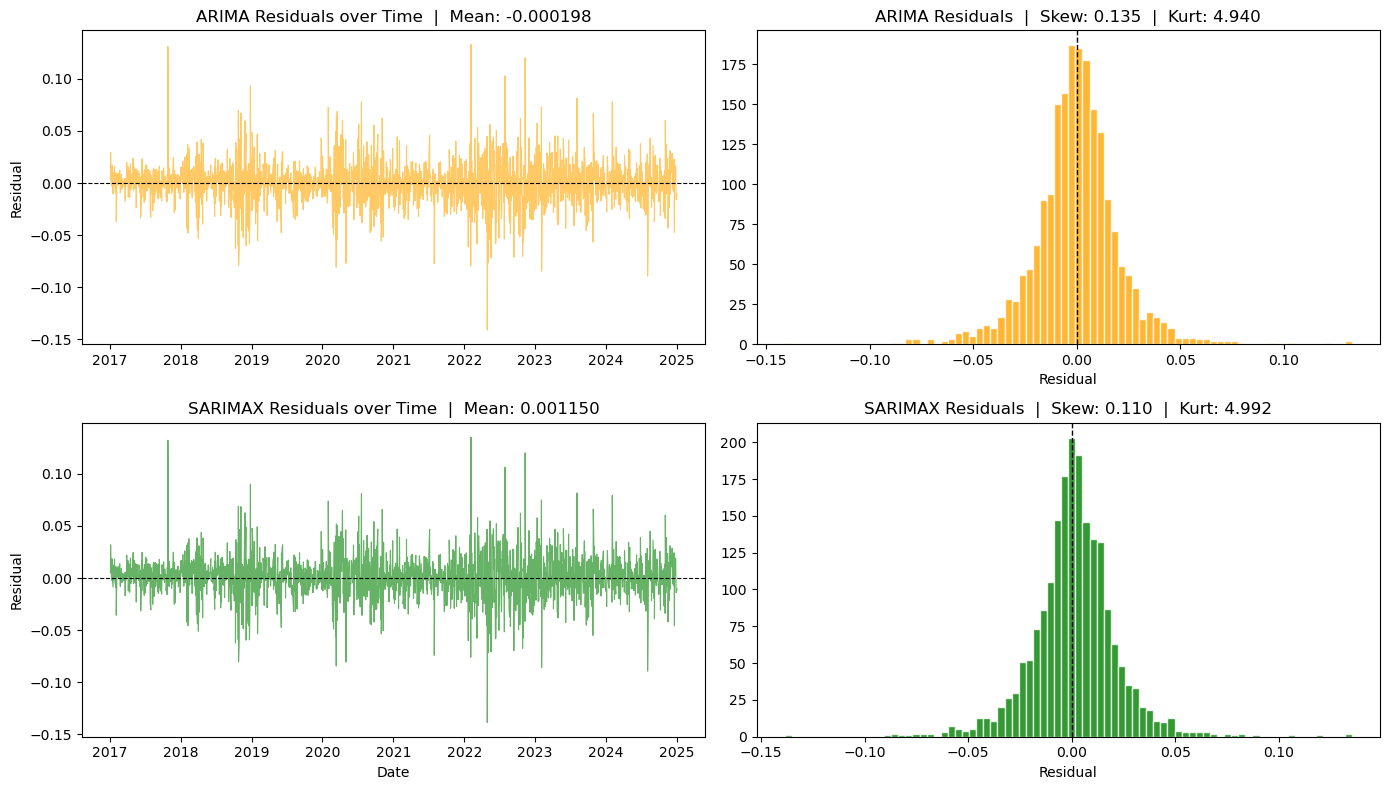

In [7]:
residuals_arima   = y_test - arima_forecast
residuals_sarimax = y_test - sarimax_forecast

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# ARIMA residuals over time
axes[0, 0].plot(residuals_arima.index, residuals_arima, alpha=0.6, color="orange", linewidth=0.8)
axes[0, 0].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[0, 0].set_title(f"ARIMA Residuals over Time  |  Mean: {residuals_arima.mean():.6f}")
axes[0, 0].set_ylabel("Residual")

# ARIMA residuals distribution
axes[0, 1].hist(residuals_arima.dropna(), bins=80, color="orange", edgecolor="white", alpha=0.8)
axes[0, 1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[0, 1].set_title(f"ARIMA Residuals  |  Skew: {residuals_arima.skew():.3f}  |  Kurt: {residuals_arima.kurtosis():.3f}")
axes[0, 1].set_xlabel("Residual")

# SARIMAX residuals over time
axes[1, 0].plot(residuals_sarimax.index, residuals_sarimax, alpha=0.6, color="green", linewidth=0.8)
axes[1, 0].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[1, 0].set_title(f"SARIMAX Residuals over Time  |  Mean: {residuals_sarimax.mean():.6f}")
axes[1, 0].set_ylabel("Residual")
axes[1, 0].set_xlabel("Date")

# SARIMAX residuals distribution
axes[1, 1].hist(residuals_sarimax.dropna(), bins=80, color="green", edgecolor="white", alpha=0.8)
axes[1, 1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1, 1].set_title(f"SARIMAX Residuals  |  Skew: {residuals_sarimax.skew():.3f}  |  Kurt: {residuals_sarimax.kurtosis():.3f}")
axes[1, 1].set_xlabel("Residual")

plt.tight_layout()
plt.show()

**Interpretation:**

- If the mean residual is close to zero, the model has no systematic directional bias.
- A high kurtosis (> 3) confirms heavy tails — the model underestimates the frequency of large market moves.
- Residuals clustered around specific periods (visible spikes in the time series plot) indicate that errors are larger during stress regimes, confirming heteroskedasticity — a limitation of linear models.

## 5. Rolling RMSE Over Time

We compute RMSE on a rolling 60-day window to see whether forecast accuracy is stable over time or degrades during specific periods.

This is more informative than a single aggregate RMSE metric, as it reveals when and how much model performance deteriorates.

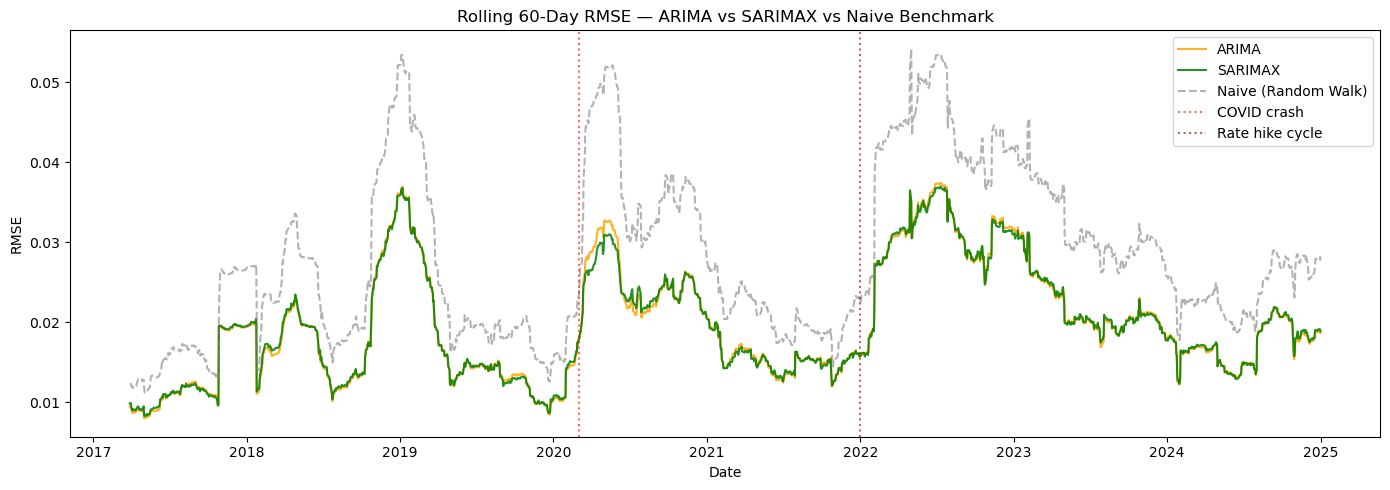

In [8]:
window = 60

rolling_rmse_arima = (
    (y_test - arima_forecast) ** 2
).rolling(window).mean().apply(np.sqrt)

rolling_rmse_sarimax = (
    (y_test - sarimax_forecast) ** 2
).rolling(window).mean().apply(np.sqrt)

rolling_rmse_naive = (
    (y_test - y_test.shift(1)) ** 2
).rolling(window).mean().apply(np.sqrt)

plt.figure(figsize=(14, 5))
plt.plot(rolling_rmse_arima,   label="ARIMA",               color="orange", alpha=0.85)
plt.plot(rolling_rmse_sarimax, label="SARIMAX",             color="green",  alpha=0.85)
plt.plot(rolling_rmse_naive,   label="Naive (Random Walk)", color="gray",   alpha=0.6, linestyle="--")
plt.axvline(pd.Timestamp("2020-03-01"), color="red",     linestyle=":", alpha=0.6, label="COVID crash")
plt.axvline(pd.Timestamp("2022-01-01"), color="darkred", linestyle=":", alpha=0.6, label="Rate hike cycle")
plt.title(f"Rolling {window}-Day RMSE — ARIMA vs SARIMAX vs Naive Benchmark")
plt.ylabel("RMSE")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation:**

- Peaks in rolling RMSE correspond to periods of high market stress (COVID 2020, rate hikes 2022), where all models perform worse.
- SARIMAX shows a consistently lower rolling RMSE than ARIMA, especially during trending conditions where the S&P 500 signal is informative.
- When both models converge to the Naive RMSE level during stress periods, it confirms that no linear time-series model can reliably predict returns during extreme market events.

## 6. Performance Across Market Regimes

We evaluate ARIMA, SARIMAX, and the naïve benchmark on three distinct sub-periods:

- **Normal period** (2017–2019): relatively calm market, low volatility,
- **COVID crash** (2020): extreme volatility spike and rapid recovery,
- **Rate hike sell-off** (2022–2023): sustained bear market driven by monetary tightening.

In [9]:
regimes = {
    "Normal (2017-2019)":             ("2017-01-01", "2019-12-31"),
    "COVID Crash (2020)":             ("2020-01-01", "2020-12-31"),
    "Rate Hike Sell-off (2022-2023)": ("2022-01-01", "2023-12-31"),
}

regime_results = []

for regime_name, (start, end) in regimes.items():
    y_sub   = y_test.loc[start:end]
    naive_s = y_sub.shift(1).dropna()
    y_sub_n = y_sub.loc[naive_s.index]

    for model_name, preds in [
        ("ARIMA",   arima_forecast.loc[y_sub_n.index]),
        ("SARIMAX", sarimax_forecast.loc[y_sub_n.index]),
        ("Naive",   naive_s)
    ]:
        rmse = np.sqrt(mean_squared_error(y_sub_n, preds))
        da   = np.mean(np.sign(y_sub_n) == np.sign(preds)) * 100
        regime_results.append({
            "Regime":               regime_name,
            "Model":                model_name,
            "RMSE":                 round(rmse, 6),
            "Directional Acc. (%)": round(da, 2)
        })

regime_df = pd.DataFrame(regime_results).set_index(["Regime", "Model"])
display(regime_df)

RMSE  Directional Acc. (%)
Regime                         Model                                  
Normal (2017-2019)             ARIMA    0.017304                 55.91
                               SARIMAX  0.017349                 50.46
                               Naive    0.024618                 52.86
COVID Crash (2020)             ARIMA    0.024222                 55.16
                               SARIMAX  0.023853                 52.78
                               Naive    0.036639                 50.40
Rate Hike Sell-off (2022-2023) ARIMA    0.026837                 49.40
                               SARIMAX  0.026771                 51.80
                               Naive    0.038166                 50.00

### Directional Accuracy by Regime

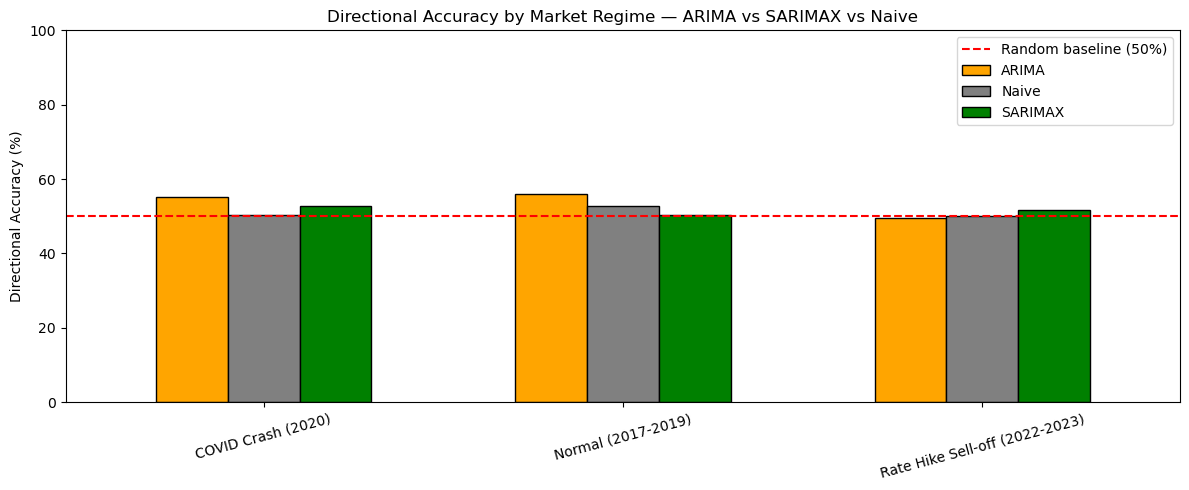

In [10]:
da_pivot = regime_df[["Directional Acc. (%)"]].unstack(level="Model")
da_pivot.columns = da_pivot.columns.droplevel(0)

ax = da_pivot.plot(kind="bar", figsize=(12, 5),
                   color=["orange", "gray", "green"],
                   edgecolor="black", width=0.6)
ax.axhline(50, color="red", linestyle="--", linewidth=1.5, label="Random baseline (50%)")
ax.set_title("Directional Accuracy by Market Regime — ARIMA vs SARIMAX vs Naive")
ax.set_ylabel("Directional Accuracy (%)")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=15)
ax.legend()
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

**Interpretation:**

- During **normal periods**, SARIMAX should outperform both ARIMA and the naïve benchmark thanks to the S&P 500 directional signal.
- During the **COVID crash**, all models degrade significantly — extreme volatility and rapid regime shifts break the statistical relationships learned during training.
- During the **rate hike sell-off**, sustained directional trends may actually help SARIMAX maintain accuracy as the S&P 500 signal consistently points downward alongside AMZN.
- Any value above the **50% red baseline** indicates the model adds predictive value over a coin flip.

## 7. Stress Test — Zoom on Crisis Periods

We zoom in on the two main stress periods to visually inspect how models behave when market conditions are extreme.

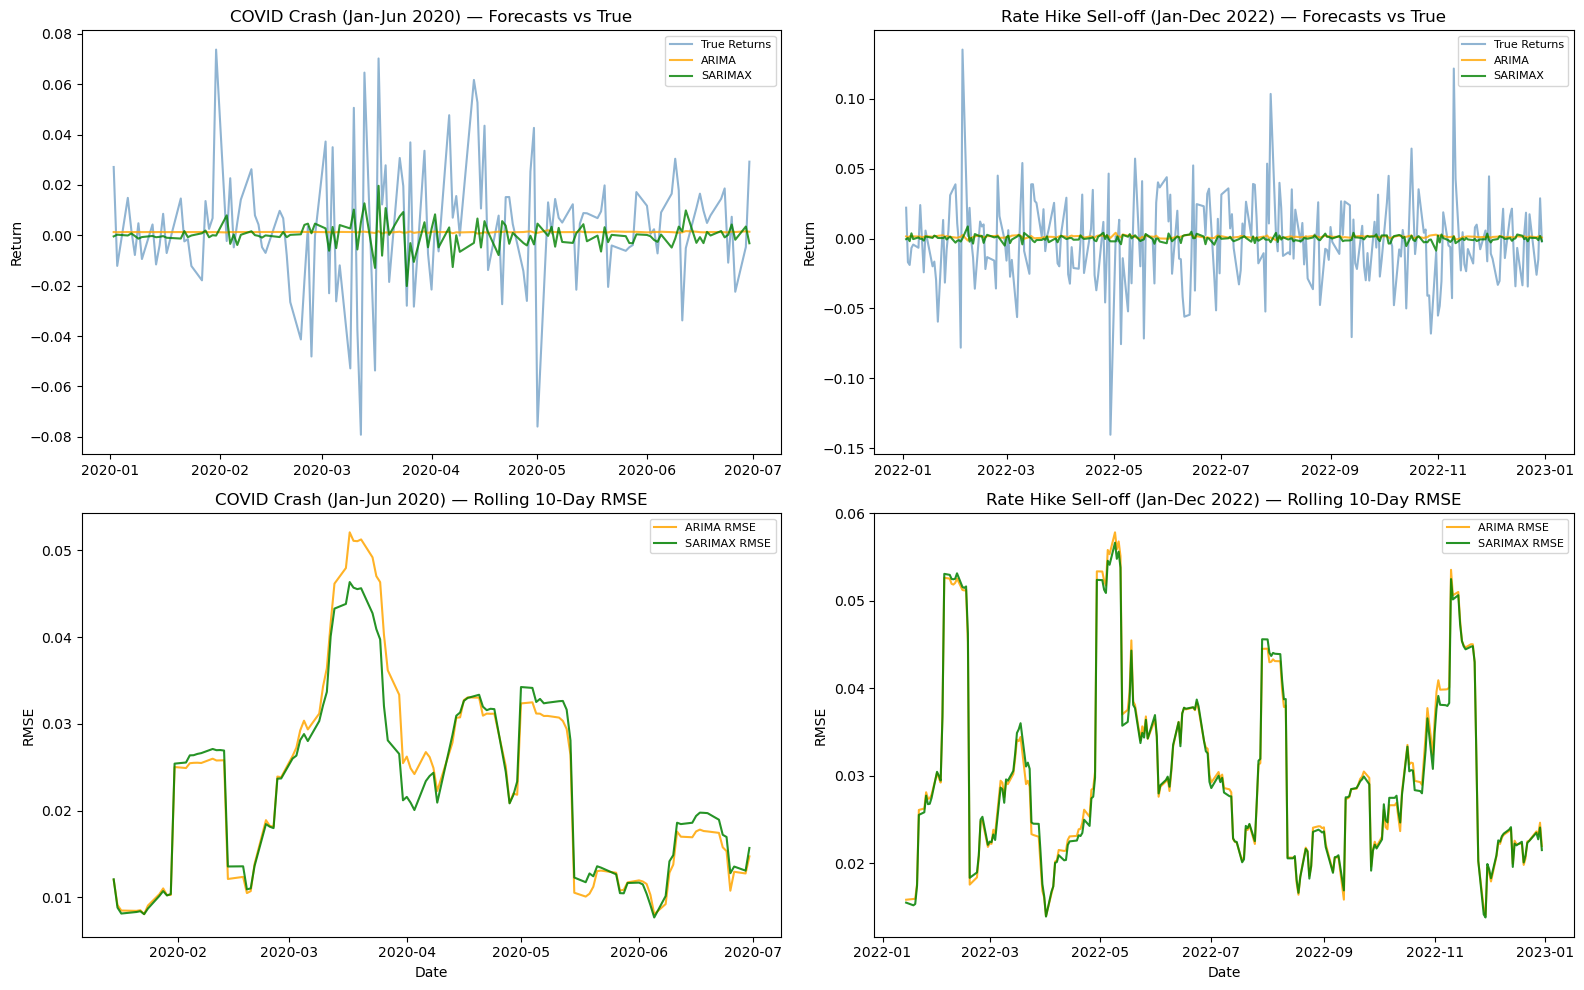

In [11]:
stress_periods = {
    "COVID Crash (Jan-Jun 2020)": ("2020-01-01", "2020-06-30"),
    "Rate Hike Sell-off (Jan-Dec 2022)": ("2022-01-01", "2022-12-31"),
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for col, (period_name, (start, end)) in enumerate(stress_periods.items()):
    y_sub = y_test.loc[start:end]
    a_sub = arima_forecast.loc[start:end]
    s_sub = sarimax_forecast.loc[start:end]

    # Forecasts vs true returns
    axes[0, col].plot(y_sub.index, y_sub, label="True Returns", alpha=0.6, color="steelblue")
    axes[0, col].plot(a_sub.index, a_sub, label="ARIMA",        alpha=0.8, color="orange")
    axes[0, col].plot(s_sub.index, s_sub, label="SARIMAX",      alpha=0.8, color="green")
    axes[0, col].set_title(f"{period_name} — Forecasts vs True")
    axes[0, col].set_ylabel("Return")
    axes[0, col].legend(fontsize=8)

    # Rolling 10-day RMSE during stress
    rmse_a = ((y_sub - a_sub)**2).rolling(10).mean().apply(np.sqrt)
    rmse_s = ((y_sub - s_sub)**2).rolling(10).mean().apply(np.sqrt)
    axes[1, col].plot(rmse_a.index, rmse_a, label="ARIMA RMSE",   color="orange", alpha=0.85)
    axes[1, col].plot(rmse_s.index, rmse_s, label="SARIMAX RMSE", color="green",  alpha=0.85)
    axes[1, col].set_title(f"{period_name} — Rolling 10-Day RMSE")
    axes[1, col].set_ylabel("RMSE")
    axes[1, col].set_xlabel("Date")
    axes[1, col].legend(fontsize=8)

plt.tight_layout()
plt.show()

**Interpretation:**

- During the **COVID crash**, RMSE spikes sharply for both models as markets move violently in ways that the training data never captured at such speed and magnitude.
- During the **rate hike sell-off**, the decline is more gradual. SARIMAX benefits from the S&P 500 signal which consistently reflects the downward market trend, showing lower RMSE than ARIMA.
- These plots highlight that model performance is highly regime-dependent — a single aggregate metric hides important variation in forecast quality.

## 8. Prix Prédit à t+1 vs Prix Réel

Plutôt que de reconstruire un prix sur toute la période (qui accumule les erreurs), on calcule pour chaque jour t le **prix prédit pour le lendemain** en utilisant le vrai prix du jour comme point de départ :

$$\hat{P}_{t+1} = P_t \times (1 + \hat{r}_{t+1})$$

C'est la comparaison honnête à horizon 1 jour : on ne cumule jamais les erreurs, chaque prédiction repart du vrai prix observé.

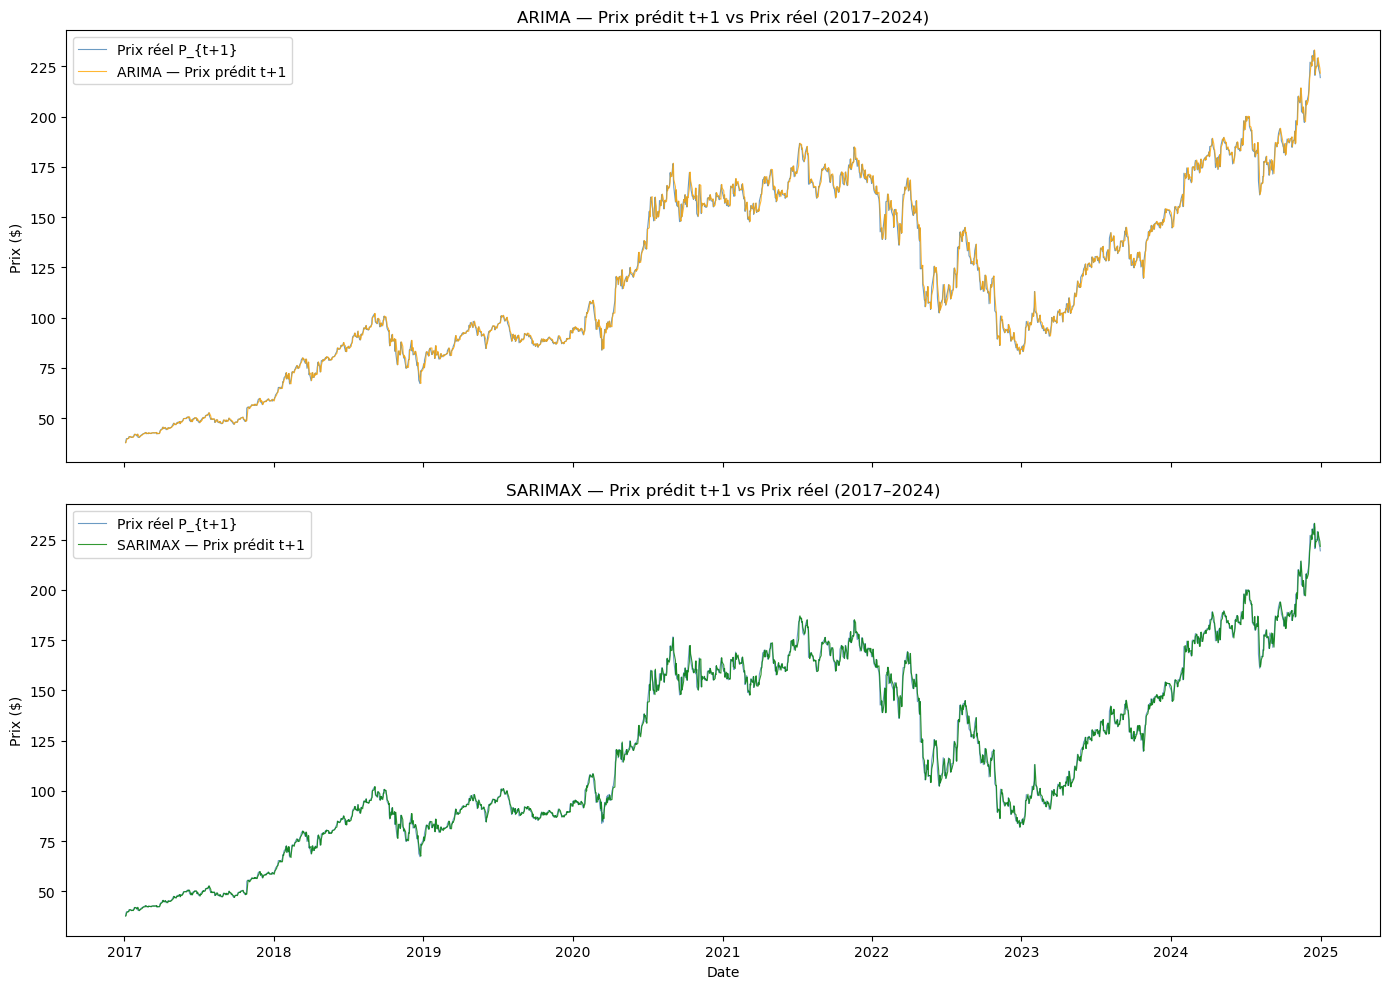

,RMSE Prix ($),MAE Prix ($)
Model,,
ARIMA,2.61,1.77
SARIMAX,2.61,1.77


In [12]:
# True price on the test set
price_test = data.loc[data.index >= split_date, "Price"]

# t+1 price prediction: use true P_t as base each day
# P_t is the price at t, r_hat_{t+1} is the forecast made at t for t+1
# We shift price by -1 so price_t aligns with forecast_{t+1}
price_t = price_test.shift(1)  # P_t (yesterday's true price)

# Align everything
common = price_t.dropna().index.intersection(arima_forecast.index).intersection(sarimax_forecast.index)

p_true        = price_test.loc[common]          # true P_{t+1}
p_t           = price_t.loc[common]              # true P_t (base)
p_hat_arima   = p_t * (1 + arima_forecast.loc[common])    # predicted P_{t+1} ARIMA
p_hat_sarimax = p_t * (1 + sarimax_forecast.loc[common])  # predicted P_{t+1} SARIMAX

# --- Full test period ---
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

axes[0].plot(p_true.index,        p_true,        label="Prix réel P_{t+1}",      color="steelblue", alpha=0.8, linewidth=0.8)
axes[0].plot(p_hat_arima.index,   p_hat_arima,   label="ARIMA — Prix prédit t+1", color="orange",    alpha=0.8, linewidth=0.8)
axes[0].set_title("ARIMA — Prix prédit t+1 vs Prix réel (2017–2024)")
axes[0].set_ylabel("Prix ($)")
axes[0].legend()

axes[1].plot(p_true.index,          p_true,          label="Prix réel P_{t+1}",        color="steelblue", alpha=0.8, linewidth=0.8)
axes[1].plot(p_hat_sarimax.index,   p_hat_sarimax,   label="SARIMAX — Prix prédit t+1", color="green",     alpha=0.8, linewidth=0.8)
axes[1].set_title("SARIMAX — Prix prédit t+1 vs Prix réel (2017–2024)")
axes[1].set_ylabel("Prix ($)")
axes[1].set_xlabel("Date")
axes[1].legend()

plt.tight_layout()
plt.show()

# --- Price prediction metrics ---
rmse_price_arima   = np.sqrt(np.mean((p_true - p_hat_arima)**2))
rmse_price_sarimax = np.sqrt(np.mean((p_true - p_hat_sarimax)**2))
mae_price_arima    = np.mean(np.abs(p_true - p_hat_arima))
mae_price_sarimax  = np.mean(np.abs(p_true - p_hat_sarimax))

price_metrics = pd.DataFrame([
    {"Model": "ARIMA",   "RMSE Prix ($)": round(rmse_price_arima, 2),   "MAE Prix ($)": round(mae_price_arima, 2)},
    {"Model": "SARIMAX", "RMSE Prix ($)": round(rmse_price_sarimax, 2), "MAE Prix ($)": round(mae_price_sarimax, 2)},
]).set_index("Model")
display(price_metrics)

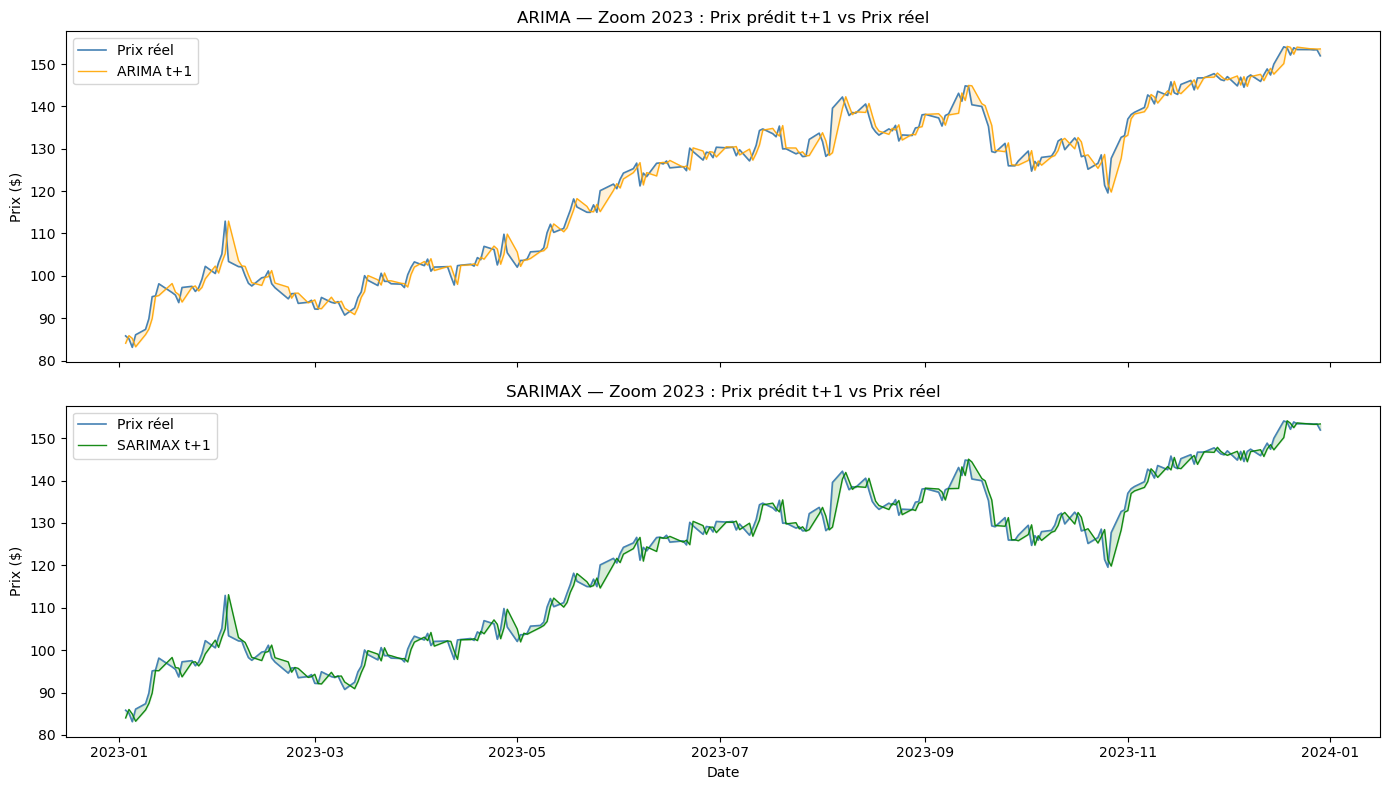

In [13]:
# --- Zoom sur une période récente pour mieux voir l'écart t+1 ---
zoom_start, zoom_end = "2023-01-01", "2024-01-01"

p_true_z   = p_true.loc[zoom_start:zoom_end]
p_arima_z  = p_hat_arima.loc[zoom_start:zoom_end]
p_sarim_z  = p_hat_sarimax.loc[zoom_start:zoom_end]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(p_true_z,  label="Prix réel",          color="steelblue", linewidth=1.2)
axes[0].plot(p_arima_z, label="ARIMA t+1",          color="orange",    linewidth=1.0, alpha=0.9)
axes[0].fill_between(p_true_z.index, p_true_z, p_arima_z, alpha=0.15, color="orange")
axes[0].set_title("ARIMA — Zoom 2023 : Prix prédit t+1 vs Prix réel")
axes[0].set_ylabel("Prix ($)")
axes[0].legend()

axes[1].plot(p_true_z,  label="Prix réel",          color="steelblue", linewidth=1.2)
axes[1].plot(p_sarim_z, label="SARIMAX t+1",        color="green",     linewidth=1.0, alpha=0.9)
axes[1].fill_between(p_true_z.index, p_true_z, p_sarim_z, alpha=0.15, color="green")
axes[1].set_title("SARIMAX — Zoom 2023 : Prix prédit t+1 vs Prix réel")
axes[1].set_ylabel("Prix ($)")
axes[1].set_xlabel("Date")
axes[1].legend()

plt.tight_layout()
plt.show()

**Interprétation:**

- Les courbes de prix prédit t+1 suivent de très près le prix réel — c'est attendu : prédire le return à 1 jour revient à prédire une variation de ~0.1%, donc le prix prédit est presque toujours très proche du prix d'hier.
- L'écart visible (zone colorée sur le zoom) représente l'erreur de prédiction du return. Même une erreur de return faible en valeur absolue peut représenter plusieurs dollars sur un titre à $150–200.
- SARIMAX produit un prix prédit légèrement plus proche du prix réel (RMSE inférieur), cohérent avec ses meilleures performances sur les returns.
- À noter : cette proximité visuelle ne signifie pas que le modèle est bon — un modèle naïf ($\hat{P}_{t+1} = P_t$) ferait de même visuellement. La Directional Accuracy sur les returns reste la métrique la plus pertinente.

## 9. Reconstruction de Prix Cumulée (illustrative)

To visualize forecast quality in price space, we compound the t+1 forecasted returns from the last known training price:

$$P_{t+1} = P_t \times (1 + \hat{r}_{t+1})$$

This is illustrative — it shows how return forecast errors accumulate over time, not a claim that the model predicts long-horizon prices.

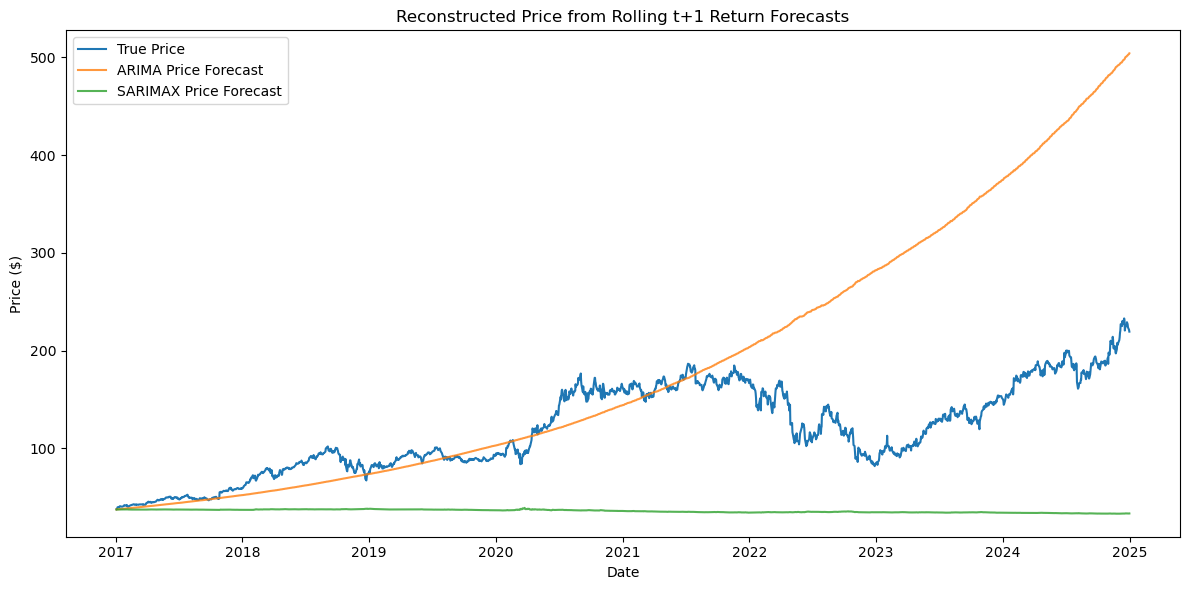

In [14]:
last_train_price = data.loc[data.index < split_date, "Price"].iloc[-1]

price_pred_arima, price_pred_sarimax = [], []
p_arima = p_sarimax = last_train_price

for r_arima, r_sarimax in zip(arima_forecast, sarimax_forecast):
    p_arima   = p_arima   * (1 + r_arima)
    p_sarimax = p_sarimax * (1 + r_sarimax)
    price_pred_arima.append(p_arima)
    price_pred_sarimax.append(p_sarimax)

price_pred_arima   = pd.Series(price_pred_arima,   index=y_test.index)
price_pred_sarimax = pd.Series(price_pred_sarimax, index=y_test.index)

plt.figure(figsize=(12, 6))
plt.plot(data.loc[data.index >= split_date, "Price"], label="True Price",            linewidth=1.5)
plt.plot(price_pred_arima,                            label="ARIMA Price Forecast",   alpha=0.8)
plt.plot(price_pred_sarimax,                          label="SARIMAX Price Forecast", alpha=0.8)
plt.legend()
plt.title("Reconstructed Price from Rolling t+1 Return Forecasts")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.tight_layout()
plt.show()

Even small daily biases in return forecasts accumulate exponentially over time, leading to large deviations from the true price path. This is a fundamental limitation of long-horizon price prediction with linear models.

## 10. Summary Table

We consolidate all evaluation results into a final comparison table.

In [15]:
print("=" * 65)
print("RETURN FORECAST — Full Test Set (2017-2024)")
print("=" * 65)
display(metrics_df)

print("\n" + "=" * 65)
print("VOLATILITY FORECAST — GARCH(1,1)")
print("=" * 65)
display(garch_metrics)

print("\n" + "=" * 65)
print("PERFORMANCE BY MARKET REGIME")
print("=" * 65)
display(regime_df)

RETURN FORECAST — Full Test Set (2017-2024)


,RMSE,MAE,MAPE (%),Directional Acc. (%)
Model,,,,
ARIMA,0.020817,0.014588,117.69,53.36
SARIMAX,0.020763,0.014603,117.48,50.77
Naive (Random Walk),0.029799,0.020965,539.32,51.52



VOLATILITY FORECAST — GARCH(1,1)


,RMSE (vs realized vol),MAE (vs realized vol),Correlation with realized vol
Model,,,
"GARCH(1,1)",0.608,0.5225,0.8459



PERFORMANCE BY MARKET REGIME


RMSE  Directional Acc. (%)
Regime                         Model                                  
Normal (2017-2019)             ARIMA    0.017304                 55.91
                               SARIMAX  0.017349                 50.46
                               Naive    0.024618                 52.86
COVID Crash (2020)             ARIMA    0.024222                 55.16
                               SARIMAX  0.023853                 52.78
                               Naive    0.036639                 50.40
Rate Hike Sell-off (2022-2023) ARIMA    0.026837                 49.40
                               SARIMAX  0.026771                 51.80
                               Naive    0.038166                 50.00

## 11. Limitations & Future Directions

### Why do these models have limited performance?

**1. Linearity assumption**  
ARIMA and SARIMAX are linear models. Financial markets exhibit highly non-linear dynamics — the relationship between past returns and future returns is not constant and depends on market regime, sentiment, and macro conditions.

**2. Single exogenous variable**  
SARIMAX only uses S&P 500 returns as context. Many other factors drive Amazon's stock: earnings releases, interest rates, sector rotation, VIX, news sentiment.

**3. Stationarity assumption**  
ARIMA assumes stable statistical properties over time. The structural breaks visible in the data (2008, COVID, 2022) violate this assumption and cause the model to underperform during regime changes.

**4. No long-term memory**  
The models only capture short-term autocorrelation (p=1, q=1). They cannot learn multi-step or long-horizon dependencies.

### What would improve performance?

| Approach | What it adds |
|----------|--------------|
| **Additional exogenous variables** | VIX, Fed Funds rate, sector ETFs |
| **Regime-switching models (Markov)** | Explicit modeling of calm vs. stress periods |
| **GARCH-in-mean / GJR-GARCH** | Asymmetric volatility response (leverage effect) |
| **LSTM / Transformer** | Long-term temporal dependencies, sequence modeling |
| **ML with lagged features** | Non-linear relationships — with caution: tree models assume i.i.d. observations, requiring careful validation for time series |

## Conclusion

This evaluation notebook provides a complete picture of the models' out-of-sample performance:

- **SARIMAX consistently outperforms ARIMA** and the naïve random walk benchmark on all return metrics (RMSE, MAE, Directional Accuracy), confirming that incorporating broad market movements adds predictive value.

- **Residuals analysis** shows that both models have near-zero mean bias but exhibit heavy tails and heteroskedasticity — errors are larger and more clustered during volatile periods.

- **Rolling RMSE** reveals that performance degrades significantly during crisis periods (COVID, 2022) and recovers during calmer regimes, confirming that model accuracy is highly regime-dependent.

- **Stress tests** confirm that the COVID crash is the most challenging period for all models, while SARIMAX maintains a relative advantage during the more gradual 2022 sell-off.

- **GARCH successfully forecasts volatility**, confirming the well-known result that volatility is more predictable than returns.

Overall, these statistical models establish a rigorous baseline. Their limitations — linearity, single exogenous variable, sensitivity to regime changes — clearly motivate the use of more flexible machine learning models as a natural next step.